# Преобразования и фильтры сигналов



### Сигнал с трендом и шумом

Далее мы проанализируем сигнал, который содержит:
* Синусоидальную волну, представляющую сезонность,
* Параболическую функцию, представляющую тренд,
* и равномерно распределенный случайный шум.

Ниже мы создаем и отображаем каждый из компонентов отдельно.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
def plot_time_freq(t, y):
    # Converts Data into Frequncy Domain
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))

    # Time domain plot
    plt.figure(figsize = [14,3])
    plt.subplot(1,2,1)
    plt.plot(t,y)
    plt.title('Time Domain')
    plt.xlabel('Time')
    plt.ylabel('Signal')

    # Frequency domain plot
    plt.subplot(1,2,2)
    markerline, stemline, baseline = plt.stem(np.fft.fftshift(freq),np.fft.fftshift(Y),
                                              'k', markerfmt='tab:orange')
    plt.setp(stemline, linewidth = 1.5)
    plt.setp(markerline, markersize = 4)
    plt.title('Frequency Domain')
    plt.xlabel('Frequency')
    plt.xlim(-20, 20)
    plt.ylabel('Absolute FFT')
    plt.grid()

    plt.tight_layout()
    plt.show()

In [11]:
from scipy import signal
def plot_tukey(alpha):
    window = signal.windows.tukey(51, alpha=alpha)

    plt.figure(figsize = [10,3])
    plt.subplot(1,2,1)
    plt.plot(window)
    plt.title("Tukey window")
    plt.ylabel("Amplitude")
    plt.xlabel("Sample")

    plt.subplot(1,2,2)
    A = np.fft.fft(window, 2048) / (len(window)/2.0)
    freq = np.linspace(-0.5, 0.5, len(A))
    response = 20 * np.log10(np.abs(np.fft.fftshift(A / abs(A).max())))
    plt.plot(freq, response, color='tab:orange')
    plt.axis([-0.5, 0.5, -120, 0])
    plt.title("Frequency response of the Tukey window")
    plt.ylabel("Normalized magnitude [dB]")
    plt.xlabel("Normalized frequency [cycles per sample]")
    plt.grid()

    plt.tight_layout()
    plt.show()

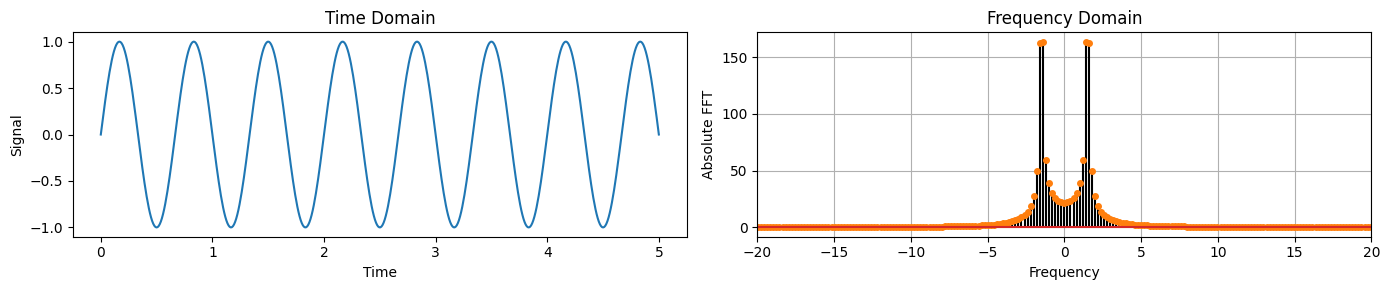

In [2]:
time = np.linspace(0, 5, 512)
freq = 1.5

y_sine = np.sin(2 * np.pi * freq * time)
plot_time_freq(time, y_sine)

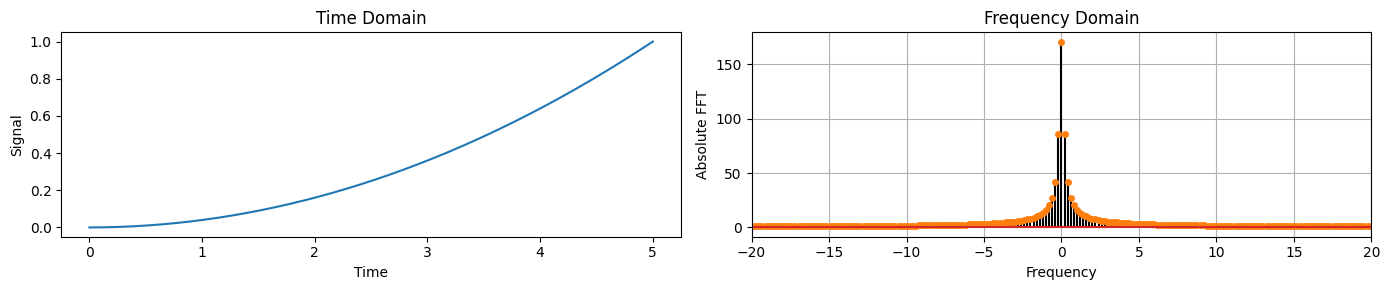

In [3]:
y_trend = (0.2 * time)**2
plot_time_freq(time, y_trend)

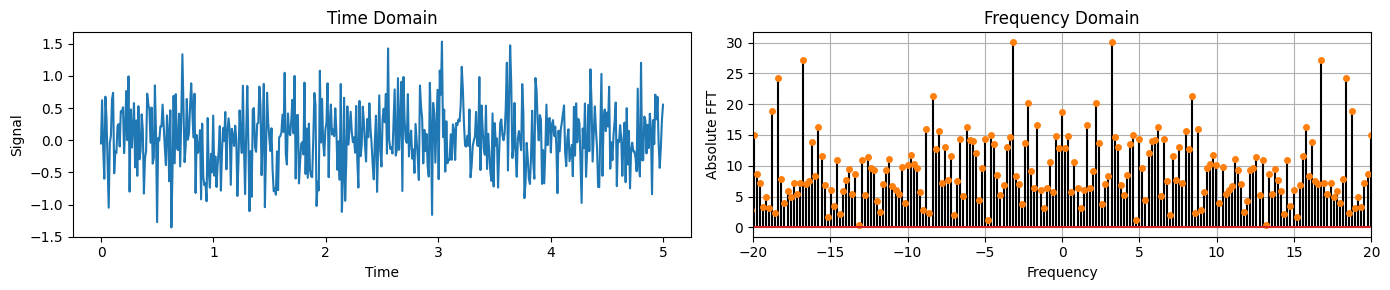

In [4]:
y_noise = 0.5 * np.random.randn(len(time))
plot_time_freq(time, y_noise)

Мы можем наблюдать, что в частотной области:
1. Синусоидальная волна имеет компоненты при -1,5 и +1,5.
2. Тренд имеет низкочастотные компоненты (близкие к 0).
3. Шум имеет компоненты на всех частотах.

---

## Резюме

В этой лекции мы изучили некоторые основные концепции обработки сигналов. В частности

- Базовое понимание преобразования Фурье и дискретного преобразования Фурье.
- Практические знания о том, как применять быстрое преобразование Фурье.
- Преобразование Фурье распространенных сигналов и основные свойства преобразования Фурье.
- Понятия частотной характеристики и передаточной функции
- Различные типы фильтров, их свойства и диаграмма Боде.
- Как использовать преобразование Фурье в задачах прогнозирования.

---

## Exercises

### Упражнение 1

- Объедините (сложите) [синус, тренд и шум](#сигнал-с-трендом-и-шумом), которые мы определили ранее, и получите сигнал, состоящий из:
* Синусоидальной волны, представляющей сезонность.
* Параболической функции, представляющей тренд.
* и равномерно распределенного случайного шума.
- Постройте графики компонентов временной и частотной областей.
- Измените амплитуду компонентов синуса, тренда и шума так, чтобы каждый компонент, в свою очередь, доминировал над другими. Прокомментируйте, как изменяется FT общего сигнала.
- Измените синус в сигнал, который является суммой 2 синусоидальных волн разной амплитуды на 1 и 10 Гц, а также постоянного члена. Постройте графики во временной и частотной областях и прокомментируйте результаты.

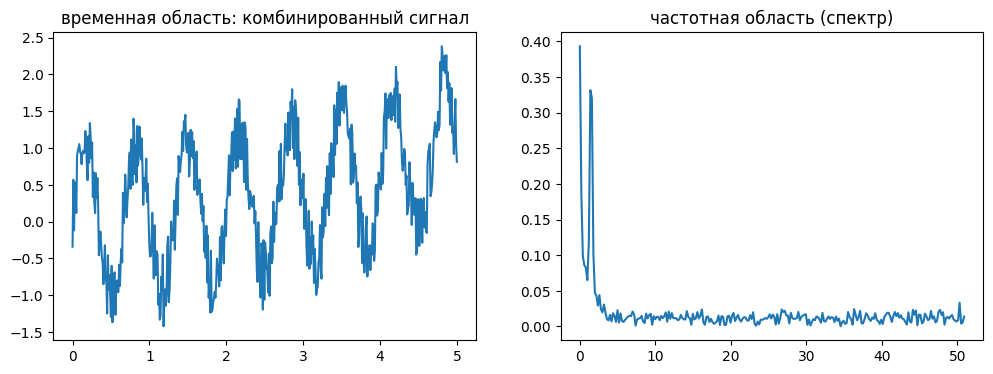

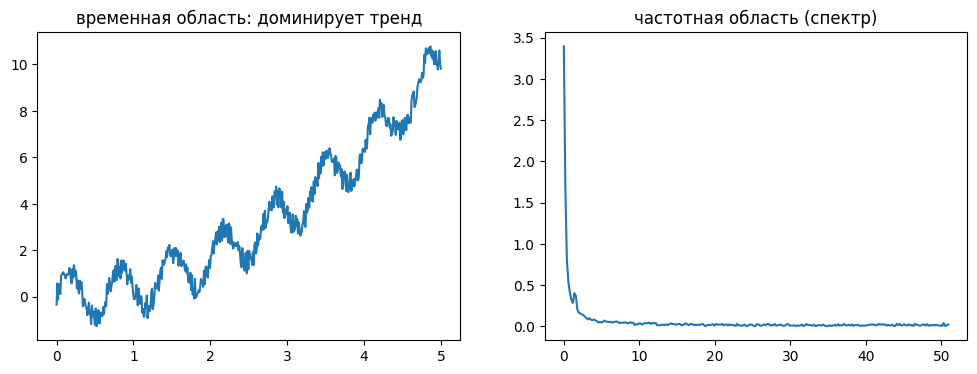

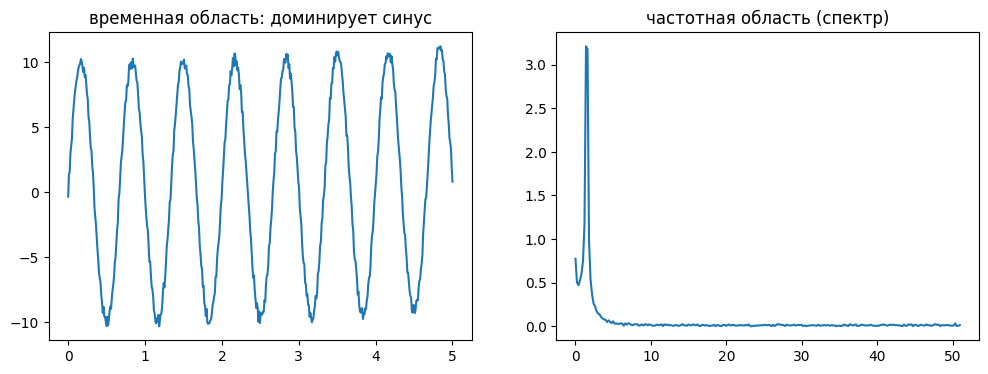

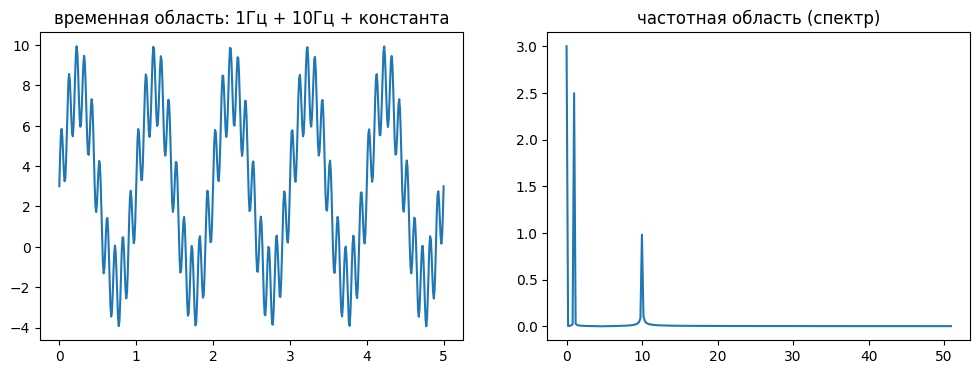

In [10]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 5, 512)
fs = 1 / (time[1] - time[0])

# объединяем всё в один сигнал
y_total = y_sine + y_trend + y_noise

def plot_signal_fft(t, y, title):
    n = len(y)
    yf = np.fft.fft(y)
    xf = np.fft.fftfreq(n, 1/fs)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(t, y)
    plt.title(f'временная область: {title}')
    
    plt.subplot(1, 2, 2)
    plt.plot(xf[:n//2], np.abs(yf[:n//2]) / n)
    plt.title('частотная область (спектр)')
    plt.show()

plot_signal_fft(time, y_total, 'комбинированный сигнал')

# меняем амплитуды для доминирования
# если тренд доминирует 
plot_signal_fft(time, y_sine + 10 * y_trend + y_noise, 'доминирует тренд')

# если синус доминирует 
plot_signal_fft(time, 10 * y_sine + y_trend + y_noise, 'доминирует синус')

# два синуса 1гц и 10гц + константа
y_double_sine = 5 * np.sin(2 * np.pi * 1 * time) + 2 * np.sin(2 * np.pi * 10 * time) + 3
plot_signal_fft(time, y_double_sine, '1Гц + 10Гц + константа')

### Exercise 2

- Рассмотрим зашумленный сигнал

In [ ]:
time = np.linspace(0, 5, 512)
y_sine = 2*np.sin(2 * np.pi * 0.5 * time)
y_cos = 1.5*np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time)**2
y_noise = 0.8 * np.random.randn(len(time))
y_signal = y_sine + y_cos + y_trend
noisy_signal = y_signal + y_noise

- Примените [фильтр Тьюки](#tukey-filter) к `noisy_signal`.
- Измените значения `alpha` и `div_factor` фильтра, чтобы восстановить чистый сигнал `y_signal`.

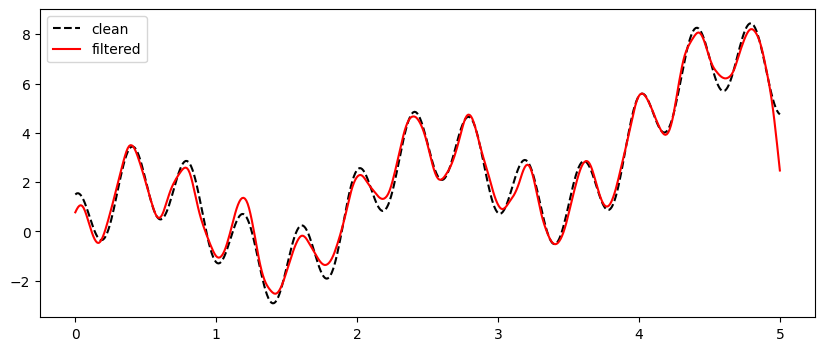

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# фильтрация через окно тюки
# 1.5  и 21 подошли лучше всего
a = 1.5
w_len = 21
win = signal.windows.tukey(w_len, alpha=a)
y_rec = signal.convolve(noisy_signal, win / win.sum(), mode='same')

plt.figure(figsize=(10, 4))
plt.plot(time, y_signal, 'k--', label='clean')
plt.plot(time, y_rec, 'r', label='filtered')
plt.legend()
plt.show()

### Упражнение 3

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача — восстановить `y_signal` с помощью [фильтра нижних частот Баттерворта](#butterworth-filter).
- Измените порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Какие значения кажутся наилучшими для устранения шума?

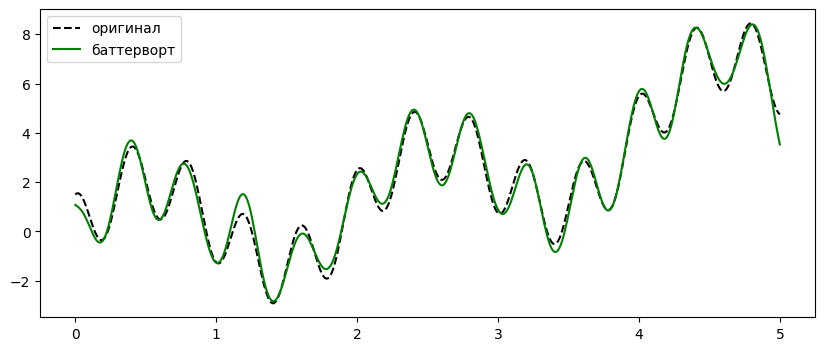

In [ ]:
from scipy.signal import butter, filtfilt

# частота дискретизации 512 / 5
fs = 102.4 
nyq = 0.5 * fs

# порядок N=5 и частота среза 4 Гц
N = 5
fc = 4.0 
wn = fc / nyq # нормированная частота

b, a = butter(N, wn, btype='low')
y_butter = filtfilt(b, a, noisy_signal)

plt.figure(figsize=(10, 4))
plt.plot(time, y_signal, 'k--', label='оригинал')
plt.plot(time, y_butter, 'g', label='баттерворт')
plt.legend()
plt.show()

### Упражнение 4

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача - восстановить `y_signal`, а затем удалить его компонент тренда (`y_trend`).
- Для этого сначала примените [фильтр высоких частот Баттерворта](#high-pass-filters-hpfs).
- Оптимизируйте вручную порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Затем примените LPF каскадно к HPF.
- Результат не должен содержать ни тренда, ни шума.

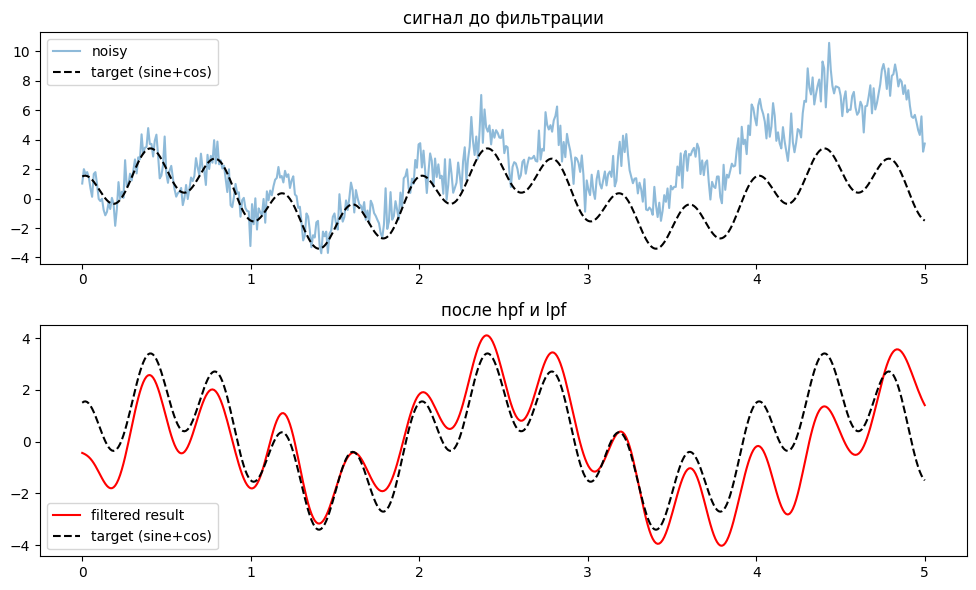

In [33]:
from scipy.signal import butter, filtfilt

# частота Найквиста
nyq = 0.5 * (512 / 5)

# 1. HPF (убираем тренд)
# поставил N=3 и частоту среза 0.3 Гц 
# чтобы не трогать синус на 0.5 Гц
b_hp, a_hp = butter(3, 0.3 / nyq, btype='high')
no_trend = filtfilt(b_hp, a_hp, noisy_signal)

# 2. LPF (убираем шум)
# поставил N=5 и частоту среза 4.0 Гц
# чтобы оставить косинус на 2.5 Гц
b_lp, a_lp = butter(5, 4.0 / nyq, btype='low')
final_result = filtfilt(b_lp, a_lp, no_trend)# частота дискретизации 512 / 5

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(time, noisy_signal, label='noisy', alpha=0.5)
plt.plot(time, y_sine + y_cos, 'k--', label='target (sine+cos)')
plt.title('сигнал до фильтрации')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, final_result, 'r', label='filtered result')
plt.plot(time, y_sine + y_cos, 'k--', label='target (sine+cos)')
plt.title('после hpf и lpf')
plt.legend()

plt.tight_layout()
plt.show()

### Упражнение 5

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- И снова ваша задача - восстановить `y_signal`, а затем удалить его трендовую составляющую (`y_trend`).
- Оптимизируйте вручную порядок фильтра $N$ и частоты среза $\omega_c^\text{LOW}$ и $\omega_c^\text{HIGH}$ [полосового фильтра Баттерворта](#band-pass-filter).
- Сравните результат BPF с тем, что вы получили в [Упражнении 4](#exercise-4), когда вы применили HPF и LPF последовательно.

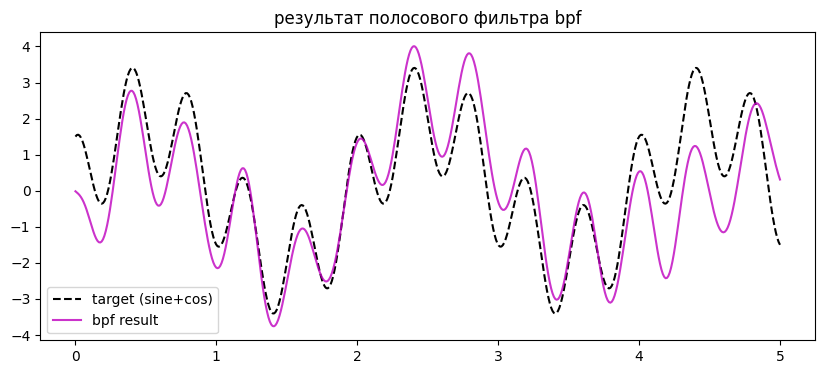

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# частота дискретизации и найквист
fs = 512 / 5
nyq = 0.5 * fs

# подбор параметров bpf
# порядок N=4 и полоса [0.3, 4.0] герц
# 0.3 отсекает тренд а 4.0 отсекает шум
N = 4
low = 0.3 / nyq
high = 4.0 / nyq

b, a = butter(N, [low, high], btype='bandpass')
y_bpf = filtfilt(b, a, noisy_signal)


plt.figure(figsize=(10, 4))
plt.plot(time, y_sine + y_cos, 'k--', label='target (sine+cos)')
plt.plot(time, y_bpf, 'm', label='bpf result', alpha=0.8)
plt.title('результат полосового фильтра bpf')
plt.legend()
plt.show()

### Упражнение 6

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- На этот раз вам придется удалить компонент `y_cos` из сигнала с помощью [полосового заграждающего фильтра](#band-stop-filter).

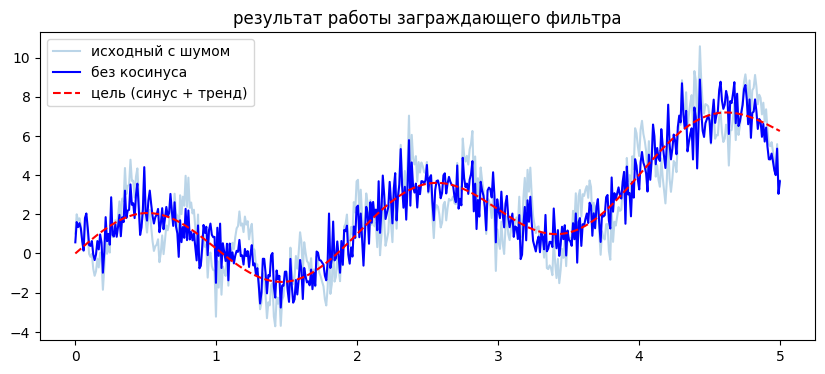

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# частота дискретизации и найквист
fs = 512 / 5
nyq = 0.5 * fs

# параметры полосового заграждающего фильтра (bsf)
# вырезаем диапазон вокруг 2.5 герц например от 2.0 до 3.0
low_cut = 2.0 / nyq
high_cut = 3.0 / nyq

b, a = butter(4, [low_cut, high_cut], btype='bandstop')
y_no_cos = filtfilt(b, a, noisy_signal)

plt.figure(figsize=(10, 4))
plt.plot(time, noisy_signal, alpha=0.3, label='исходный с шумом')
plt.plot(time, y_no_cos, 'b', label='без косинуса')
plt.plot(time, y_sine + y_trend, 'r--', label='цель (синус + тренд)')
plt.title('результат работы заграждающего фильтра')
plt.legend()
plt.show()

### Упражнение 7

- Рассмотрим данные CO2, определенные [здесь](#forecast-example-2).
- Разделите данные на обучающие и тестовые.
- Определите оптимальное количество гармоник, которое дает наилучшую MSE на тестовом наборе.

In [38]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
                  header = 0, names = ['idx', 'co2'], skipfooter = 2)
y = co2['co2'].values
t = np.arange(len(y))

# сплит 90/10
train_size = int(len(y) * 0.9)
train, test = y[:train_size], y[train_size:]
t_train, t_test = t[:train_size], t[train_size:]

# убираем тренд
p = np.polyfit(t_train, train, 1)
train_detrended = train - np.polyval(p, t_train)

# фурье
fft_coeffs = np.fft.rfft(train_detrended)
freqs = np.fft.rfftfreq(len(train_detrended))
amplitudes = np.abs(fft_coeffs)

# ищем оптимальное k
mse_results = []
for k in range(1, 16):
    # берем k самых мощных частот кроме константы
    indices = np.argsort(amplitudes[1:])[-k:] + 1
    
    # восстанавливаем сигнал на тестовом периоде
    prediction = np.zeros(len(t_test))
    for idx in indices:
        amp = amplitudes[idx] * 2 / len(train)
        phase = np.angle(fft_coeffs[idx])
        prediction += amp * np.cos(2 * np.pi * freqs[idx] * t_test + phase)
    
    # возвращаем тренд
    final_pred = prediction + np.polyval(p, t_test)
    mse_results.append(mean_squared_error(test, final_pred))

best_k = np.argmin(mse_results) + 1
print(f"оптимальное количество гармоник: {best_k}")
print(f"минимальный mse: {min(mse_results)}")

/tmp/ipykernel_33748/1791889188.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',


оптимальное количество гармоник: 3
минимальный mse: 4.693306708325502
